In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score ,confusion_matrix,classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier


Data  Load


In [2]:
data=pd.read_csv("C:\\Users\\ASUS\\Desktop\\data_science\\Project\\public_transport_delays.csv")
data.head()

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,NaN,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,NaN,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,NaN,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,NaN,500,46,0,0,6,Spring,1


Data Info

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   str    
 1   date                        2000 non-null   str    
 2   time                        2000 non-null   str    
 3   transport_type              2000 non-null   str    
 4   route_id                    2000 non-null   str    
 5   origin_station              2000 non-null   str    
 6   destination_station         2000 non-null   str    
 7   scheduled_departure         2000 non-null   str    
 8   scheduled_arrival           2000 non-null   str    
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   str    
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 non-null   

Data Cleaning/Data Preprocessing


In [4]:
data.isnull().sum()
data.dropna(inplace=True)
 

Feature Engineering   


Importanct Features:
 .weather
 .event
 .temperature
 .hour
 .day_of_week
 .traffic_level

In [5]:
data['date']=pd.to_datetime(data['date'])
data['hour']=data['date'].dt.hour
data['day_of_week']=data['date'].dt.dayofweek
 

Select Feature


In [6]:
X = data[['temperature_C','weather_condition','event_type','hour','day_of_week']]
y = data['delayed']

Encoding

In [7]:
encod=pd.get_dummies(X,columns=['weather_condition','event_type'])

In [11]:
X_train,X_test,y_train,y_test=train_test_split(encod,y,test_size=0.2,random_state=42)


Train Machine Learning Model-01(RandomForestClassifier)

In [12]:
model=RandomForestClassifier() 
model.fit(X_train , y_train)
predict=model.predict(X_test)
accuracy=accuracy_score(y_test,predict)
accuracy

0.6686746987951807

Train Machine Learning Model-02(Decision tree)

In [13]:
model=DecisionTreeClassifier().fit(X_train,y_train)
predict=model.predict(X_test)
accuracy=accuracy_score(y_test,predict)
accuracy

0.5542168674698795

Delay Distribution


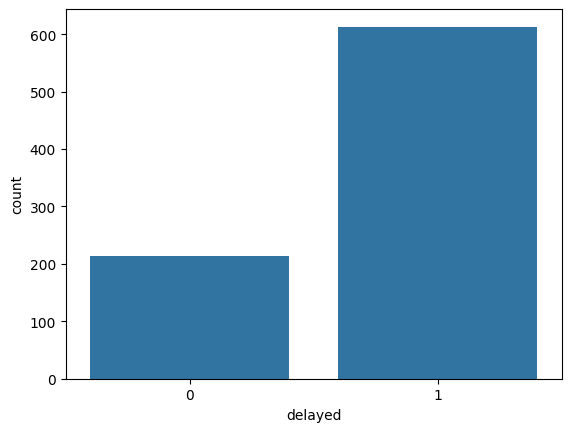

In [20]:
sns.countplot(x='delayed',data=data)
plt.show()

Weather VS Delay

In [2]:
sns.countplot(x='weather_condition',data=data,hue='delayed')

NameError: name 'sns' is not defined

Event impact

<Axes: xlabel='event_type', ylabel='count'>

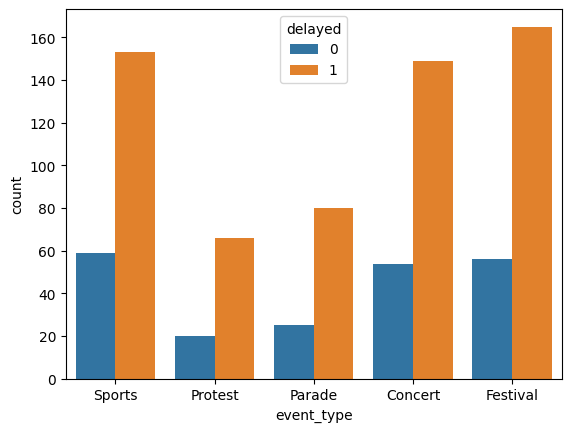

In [22]:
sns.countplot(x='event_type',hue='delayed',data=data)

In [1]:
importance=model.feature_importances_
plt.bar(encod.columns, importance)
plt.title("Feature Importance")
plt.xticks(rotation=90, ha='right')  # ha='right' aligns text nicely
plt.tight_layout()  
plt.show()

NameError: name 'model' is not defined

Conclusion:


Weather, events, and time strongly influence delays

Random Forest provides better prediction accuracy

Feature engineering improved model performance

This model can help improve transport planning